# 实验：Hoel Figure 2 toy example 与 micro-mechanism family

这个 notebook 只保留两条主线。第一条主线是严格对齐 Hoel Figure 2 的 toy example，
用它来展示 `4` 个微观节点、`2+2` 粗粒化和分解式之间的关系。第二条主线是在这个例子的基础上构造一个
Hoel Figure 2 micro-mechanism family：直接在原文 Figure 2 的 micro mechanism 表上扫描局部噪声强度。

为了让 family-level 统计更容易解释，notebook 里的大规模实验固定在 Hoel 原例的一维参数扫描上：
- Hoel 基线例子保留 `q_off = 0.30`；
- family 统计枚举 `21` 个系统：只把 `q_off` 从 `0.00` 扫描到 `1.00`；
- 对这 `21` 个系统里的每一个系统，我们都重新完整枚举 `147` 个 `2+2` 候选粗粒化，并分别计算三组相关系数；
- 单例部分仍然展示 Hoel Figure 2 的散点图，family 部分则不再为每个系统单独作图，只汇总它们的相关系数分布。


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = next(
    candidate for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / "utils.py").exists()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from IPython.display import HTML, SVG, display
except Exception:  # pragma: no cover
    HTML = None
    SVG = None
    display = None

from utils import (
    RQ3_BOOLEAN_DEFAULT_CACHE_DIR as DEFAULT_CACHE_DIR,
    RQ3_BOOLEAN_DEFAULT_CACHE_VERSION as DEFAULT_CACHE_VERSION,
    RQ3_BOOLEAN_DEFAULT_RESULTS_DIR as DEFAULT_RESULTS_DIR,
    run_statistical_reverse_experiment,
)


In [2]:
CACHE_VERSION = DEFAULT_CACHE_VERSION
CACHE_DIR = DEFAULT_CACHE_DIR
RESULTS_DIR = DEFAULT_RESULTS_DIR
REFRESH_CACHE = False
WRITE_ARTIFACTS = True
DISPLAY_INLINE = display is not None and HTML is not None and SVG is not None


In [3]:
analysis = run_statistical_reverse_experiment(
    cache_dir=CACHE_DIR,
    results_dir=RESULTS_DIR,
    cache_version=CACHE_VERSION,
    refresh_cache=REFRESH_CACHE,
    write_artifacts=WRITE_ARTIFACTS,
)

RQ3_RESULTS = analysis["RQ3_RESULTS"]
HOEL_EXAMPLE_ROW = analysis["HOEL_EXAMPLE_ROW"]
FAMILY_SYSTEM_ROWS = analysis["FAMILY_SYSTEM_ROWS"]
FAMILY_RHO_ROWS = analysis["FAMILY_RHO_ROWS"]
FAMILY_TERM_STATS = analysis["FAMILY_TERM_STATS"]
hoel_example_scatter_svg = analysis["hoel_example_scatter_svg"]
family_distribution_svg = analysis["family_distribution_svg"]
summary_html = analysis["summary_html"]
hoel_example_html = analysis["hoel_example_html"]
family_stats_html = analysis["family_stats_html"]
CACHE_FILE = analysis["CACHE_FILE"]
FAMILY_CSV_FILE = analysis["FAMILY_CSV_FILE"]
FAMILY_RHO_CSV_FILE = analysis["FAMILY_RHO_CSV_FILE"]
HOEL_CANDIDATE_CSV_FILE = analysis["HOEL_CANDIDATE_CSV_FILE"]


In [4]:
if DISPLAY_INLINE:
    display(HTML(summary_html))
    display(HTML(hoel_example_html))


Metric,Value
Hoel baseline q_off,0.300
Family systems,21
Per-term rho points,21
q_off slices,21
q_off range,0.00 to 1.00
2+2 candidate count,147


Metric,Value
micro EI,1.149
best macro EI,1.552
candidate count,147
q_off,0.300


## Hoel Figure 2 toy example

这里保留单个严格对齐 Hoel Figure 2 的例子，作为整个 notebook 的参考点。
对这个例子我们仍然枚举全部 `147` 个 `2+2` 候选粗粒化：三种两两分组，
以及每个块上全部七个代表性二值满射映射。散点图的纵轴固定为 `EI(Z->X+)`，
横轴依次是 `neg. syn`、`neg. loss` 和 `Syn macro`，因此它展示的是单个 Hoel 系统内部
候选粗粒化之间的分解结构。


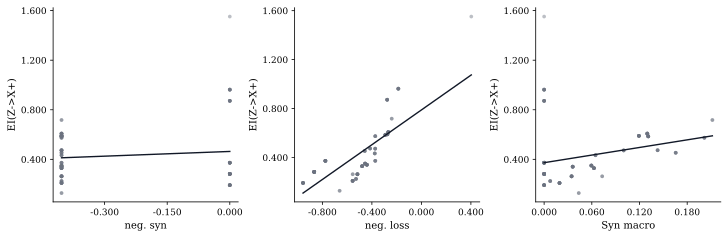

In [5]:
if DISPLAY_INLINE:
    display(SVG(hoel_example_scatter_svg))


对 Hoel 基线例子来说，`EI(S_m) = 1.149`，最优宏观 `EI(S_M) = 1.552`，
与论文里的 `1.15 / 1.55` 对齐。这里 `EI(Z->X+)` 与 `EI(S_M)` 恰好取到同一个数值，
是因为 Hoel 的 planted `2+2` 粗粒化同时也是这个例子里最优的宏观候选；因此虽然纵轴标的是 `EI(Z->X+)`，
最高点仍然会落在 `1.552` 附近。这是这个 Hoel toy example 的特例，不应把它当成一般恒等式。


## Hoel Figure 2 micro-mechanism family

family 的构造尽量贴近 Hoel 原文 Figure 2。我们不再额外引入共享噪声参数，只保留原例里 noisy AND 的局部机制，
并直接在 micro mechanism 表上扫描 `q_off`。这里 `q_off` 表示：当两输入不是 `11` 时，单个微观节点在下一时刻取值 `1` 的概率。
因此在 family 统计里，`q_off` 从 `0.00` 到 `1.00` 均匀扫描，共得到 `21` 个系统。

按照 Hoel Figure 2 的构造，若某个微观节点的两输入在时刻 `t-1` 记为 `ij \in \{00,01,10,11\}`，
则它在时刻 `t` 取值 `0/1` 的局部机制表可以写成
$$
P(1 \mid 00) = P(1 \mid 01) = P(1 \mid 10) = q_{\mathrm{off}},
\qquad
P(1 \mid 11) = 1.
$$
等价地，
$$
P(0 \mid 00) = P(0 \mid 01) = P(0 \mid 10) = 1 - q_{\mathrm{off}},
\qquad
P(0 \mid 11) = 0.
$$
在当前实现里，四个微观节点都使用这同一张 Hoel-style 局部机制表，并按 Figure 2 的连线方式组成整个 `16 x 16` 微观 TPM。
family 统计的关键点是：这里不再固定 Hoel 的 `2+2` 描述直接读分解量，而是对 `21` 个系统逐一重做和 Hoel 单例相同的 candidate 枚举。
也就是说，每个 family 系统都会重新遍历完整的 `147` 个 `2+2` 候选粗粒化，并计算
`rho(neg. syn, EI(Z->X+))`、`rho(neg. loss, EI(Z->X+))` 与 `rho(Syn macro, EI(Z->X+))`。
这里 `Syn macro` 采用与 `EI(Z->X+)` 一致的干预口径：先构造 `Z->X+` TPM，
再在该 TPM 上对另一个宏变量做均匀边缘化来计算 `EI(Z_1->X+)` 与 `EI(Z_2->X+)`，
即 `Syn macro = EI(Z->X+) - EI(Z_1->X+) - EI(Z_2->X+)`。
因此 family-level 结果可以直接解释为：当 Hoel 原例的 micro mechanism 表随着 `q_off` 改变时，Hoel 风格相关结构本身会如何在系统族上分布。


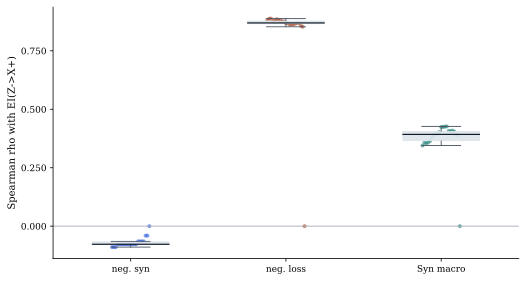

term,mean rho,std,min,max
neg. syn,-0.070,0.020094,-0.089631,0.000000
neg. loss,0.831,0.186039,0.000000,0.887825
Syn macro,0.374,0.087001,0.000000,0.426759


In [6]:
if DISPLAY_INLINE:
    display(SVG(family_distribution_svg))
    display(HTML(family_stats_html))


## Family-level decomposition statistics

这张箱图汇总了 `21` 个 family 系统上的三组相关系数分布。
这里每一个点都对应一个具体系统 `q_off`：先在该系统上完整枚举 `147` 个 `2+2` 候选粗粒化，再计算
`rho(neg. syn, EI(Z->X+))`、`rho(neg. loss, EI(Z->X+))` 和 `rho(Syn macro, EI(Z->X+))`。
因此现在比较的是：当系统参数变化时，哪一种 Hoel 风格解释项更稳定地成为系统内部 candidate 排序的主导因素。
换句话说，箱图里的样本单位是“系统”，而不是“`q_off` 切片”。
因此该统计口径与定理中的非负性条件一致。


In [7]:
assert int(RQ3_RESULTS["candidate_count_per_system"]) == 147
assert int(RQ3_RESULTS["pair_partition_count"]) == 3
assert int(RQ3_RESULTS["n_family_systems"]) == 21
assert int(RQ3_RESULTS["n_family_rho_points"]) == 21
assert int(RQ3_RESULTS["n_family_q_off_slices"]) == 21
assert len(FAMILY_SYSTEM_ROWS) == 21
assert len(FAMILY_RHO_ROWS) == 21
assert float(FAMILY_TERM_STATS["neg_loss_sum"]["mean_rho"]) > float(FAMILY_TERM_STATS["syn_macro"]["mean_rho"])
assert float(FAMILY_TERM_STATS["syn_macro"]["mean_rho"]) > float(FAMILY_TERM_STATS["neg_syn_micro"]["mean_rho"])
